In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class GATLayer(nn.Module):
    def __init__(self, g, in_dim, out_dim):
        super(GATLayer, self).__init__()
        self.g = g
        self.fc = nn.Linear(in_dim, out_dim, bias=False)
        self.attn_fc = nn.Linear(2 * out_dim, 1, bias=False)
        self.reset_parameters()

    def reset_parameters(self):
        """Reinitialize learnable parameters."""
        gain = nn.init.calculate_gain('relu')
        nn.init.xavier_normal_(self.fc.weight, gain=gain)
        nn.init.xavier_normal_(self.attn_fc.weight, gain=gain)

    def edge_attention(self, edges):
        z2 = torch.cat([edges.src['z'], edges.dst['z']], dim=1)
        a = self.attn_fc(z2)
        return {'e': F.leaky_relu(a)}

    def message_func(self, edges):
        return {'z': edges.src['z'], 'e': edges.data['e']}

    def reduce_func(self, nodes):
        alpha = F.softmax(nodes.mailbox['e'], dim=1)
        h = torch.sum(alpha * nodes.mailbox['z'], dim=1)
        return {'h': h}

    def forward(self, h):
        z = self.fc(h)
        self.g.ndata['z'] = z
        self.g.apply_edges(self.edge_attention)
        self.g.update_all(self.message_func, self.reduce_func)
        return self.g.ndata.pop('h')
    
    
class MultiHeadGATLayer(nn.Module):
    def __init__(self, g, in_dim, out_dim, num_heads, merge='cat'):
        super(MultiHeadGATLayer, self).__init__()
        self.heads = nn.ModuleList()
        for i in range(num_heads):
            self.heads.append(GATLayer(g, in_dim, out_dim))
        self.merge = merge

    def forward(self, h):
        head_outs = [attn_head(h) for attn_head in self.heads]
        if self.merge == 'cat':
            return torch.cat(head_outs, dim=1)
        else:
            return torch.mean(torch.stack(head_outs))
        
        
class GAT(nn.Module):
    def __init__(self, g, in_dim, hidden_dim, out_dim, num_heads):
        super(GAT, self).__init__()
        self.layer1 = MultiHeadGATLayer(g, in_dim, hidden_dim, num_heads)
        self.layer2 = MultiHeadGATLayer(g, hidden_dim * num_heads, out_dim, 1)
        # self.fc = nn.Linear()

    def forward(self, h):
        h = self.layer1(h)
        h = F.elu(h)
        h = self.layer2(h)
        print(h.shape)
        return h

In [18]:
from dgl.data import CoraGraphDataset

dataset = CoraGraphDataset()
g = dataset[0]
features = g.ndata["feat"]
labels = g.ndata["label"]
train_mask = g.ndata["train_mask"]
test_mask = g.ndata["test_mask"]

g


  NumNodes: 2708
  NumEdges: 10556
  NumFeats: 1433
  NumClasses: 7
  NumTrainingSamples: 140
  NumValidationSamples: 500
  NumTestSamples: 1000
Done loading data from cached files.


Graph(num_nodes=2708, num_edges=10556,
      ndata_schemes={'feat': Scheme(shape=(1433,), dtype=torch.float32), 'label': Scheme(shape=(), dtype=torch.int64), 'test_mask': Scheme(shape=(), dtype=torch.bool), 'val_mask': Scheme(shape=(), dtype=torch.bool), 'train_mask': Scheme(shape=(), dtype=torch.bool)}
      edata_schemes={})

In [9]:
features.shape, labels.shape, train_mask.shape, test_mask.shape

(torch.Size([2708, 1433]),
 torch.Size([2708]),
 torch.Size([2708]),
 torch.Size([2708]))

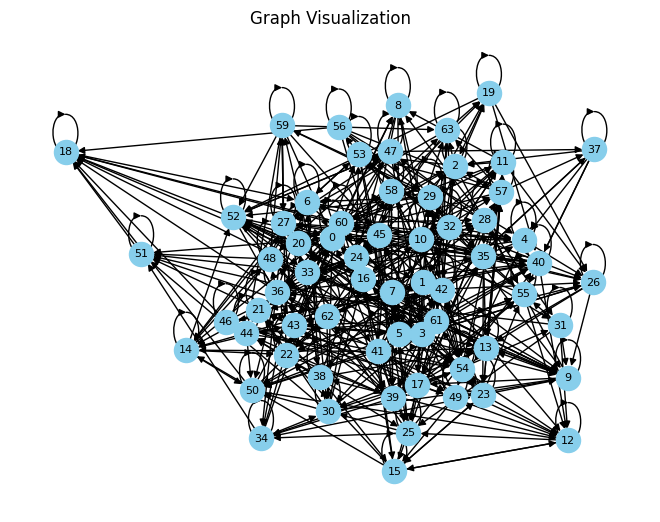

Graph(num_nodes=64, num_edges=467,
      ndata_schemes={'feat': Scheme(shape=(8,), dtype=torch.float32)}
      edata_schemes={})

In [40]:
import dgl
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

dim_0 = 4
dim_1 = 4
dim_2 = 4
feature_size = 8

num_nodes = dim_0 * dim_1 * dim_2
p_edge = 0.1

src = []
dst = []
for i in range(num_nodes):
    for j in range(num_nodes):
        if i != j and np.random.rand() < p_edge:
            src.append(i)
            dst.append(j)

g = dgl.graph((src, dst))
g =  dgl.add_self_loop(g)

node_features = torch.randn(num_nodes, feature_size)
g.ndata['feat'] = node_features

nx_g = g.to_networkx()

pos = nx.spring_layout(nx_g)  
nx.draw(nx_g, pos, with_labels=True, node_size=300, node_color='skyblue', font_size=8)
plt.title('Graph Visualization')
plt.show()


g

In [43]:
node_features.shape

torch.Size([64, 8])

In [47]:
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.nn import GATConv


class GAT(nn.Module):
    def __init__(self, g, in_dim, hidden_dim, out_dim, num_heads):
        super(GAT, self).__init__()
        self.layer1 = GATConv(in_dim, hidden_dim, num_heads)
        self.layer2 = GATConv(hidden_dim * num_heads, out_dim, 1)
        self.classifier = nn.Linear(out_dim * num_heads, in_dim)

    def forward(self, g, features):
        h = self.layer1(g, features).flatten(1)
        h = F.elu(h)
        h = self.layer2(g, h).mean(1)
        output = self.classifier(h)
        return F.log_softmax(output, dim=1)


dim_0 = 4  # 240
dim_1 = 4  # 240
dim_2 = 4  # 154
feature_size = 8  # number of in_channels from encoder
in_dim = dim_0 * dim_1 * dim_2

model = GAT(g, in_dim=feature_size, hidden_dim=32, out_dim=32, num_heads=1)

output = model(g, node_features)
output.shape


torch.Size([64, 8])

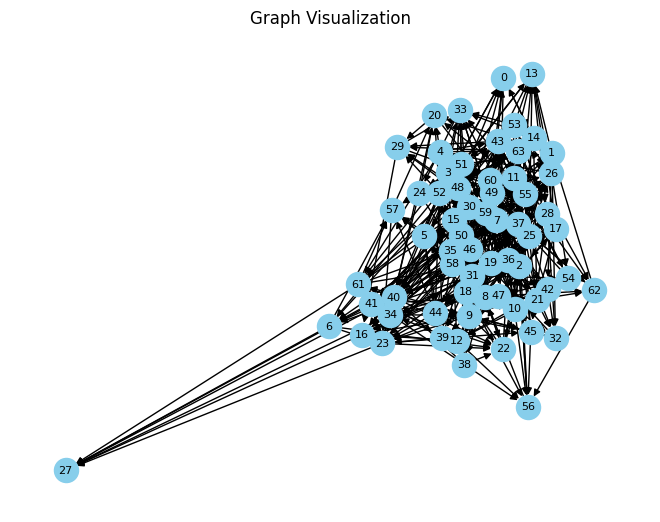

In [14]:
import time
import numpy as np


# create the model, 2 heads, each head has hidden size 8
net = GAT(g, in_dim=features.size()[1], hidden_dim=8, out_dim=7, num_heads=2)

# create optimizer
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

# main loop
dur = []
for epoch in range(30):
    if epoch >= 3:
        t0 = time.time()

    logits = net(features)
    logp = F.log_softmax(logits, 1)
    loss = F.nll_loss(logp[train_mask], labels[train_mask])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch >= 3:
        dur.append(time.time() - t0)

    print(
        "Epoch {:05d} | Loss {:.4f} | Time(s) {:.4f}".format(
            epoch, loss.item(), np.mean(dur)
        )
    )

/home/tryfonm/projects/thesis/venv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/tryfonm/projects/thesis/venv/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Epoch 00000 | Loss 1.9469 | Time(s) nan
Epoch 00001 | Loss 1.9449 | Time(s) nan
Epoch 00002 | Loss 1.9429 | Time(s) nan
Epoch 00003 | Loss 1.9409 | Time(s) 0.1498
Epoch 00004 | Loss 1.9390 | Time(s) 0.1308
Epoch 00005 | Loss 1.9370 | Time(s) 0.1203
Epoch 00006 | Loss 1.9350 | Time(s) 0.1153
Epoch 00007 | Loss 1.9331 | Time(s) 0.1127
Epoch 00008 | Loss 1.9311 | Time(s) 0.1109
Epoch 00009 | Loss 1.9291 | Time(s) 0.1108
Epoch 00010 | Loss 1.9271 | Time(s) 0.1094
Epoch 00011 | Loss 1.9251 | Time(s) 0.1087
Epoch 00012 | Loss 1.9231 | Time(s) 0.1085
Epoch 00013 | Loss 1.9211 | Time(s) 0.1085
Epoch 00014 | Loss 1.9191 | Time(s) 0.1087
Epoch 00015 | Loss 1.9171 | Time(s) 0.1083
Epoch 00016 | Loss 1.9150 | Time(s) 0.1083
Epoch 00017 | Loss 1.9130 | Time(s) 0.1078
Epoch 00018 | Loss 1.9109 | Time(s) 0.1076
Epoch 00019 | Loss 1.9089 | Time(s) 0.1073
Epoch 00020 | Loss 1.9068 | Time(s) 0.1071
Epoch 00021 | Loss 1.9047 | Time(s) 0.1067
Epoch 00022 | Loss 1.9026 | Time(s) 0.1063
Epoch 00023 | Loss 1